In [1]:
import os
import pandas as pd
from datetime import timedelta

In [2]:
df = pd.read_csv('gpu_slurm_metrics_10s_cleaned.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259185 entries, 0 to 1259184
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   timestamp               1259185 non-null  object 
 1   gpu_index               1259185 non-null  int64  
 2   utilization_gpu_pct     1259185 non-null  float64
 3   utilization_memory_pct  1259185 non-null  float64
 4   temperature_gpu         1259185 non-null  float64
 5   temperature_memory      1259185 non-null  float64
 6   power_draw_W            1259185 non-null  float64
 7   id_job                  1259185 non-null  int64  
 8   time_start              1259185 non-null  float64
 9   time_end                1259185 non-null  float64
dtypes: float64(7), int64(2), object(1)
memory usage: 96.1+ MB


In [6]:
IDLE_THRESHOLD = 30  # Utilization (%) below which GPU is considered idle
INTERVAL_SECONDS = 10 

In [7]:
# Detect idle periods
df['is_idle'] = df['utilization_gpu_pct'] < IDLE_THRESHOLD

# Energy wasted during idle (Power * Time)
df['idle_energy_J'] = df['is_idle'] * df['power_draw_W'] * INTERVAL_SECONDS
df['total_energy_J'] = df['power_draw_W'] * INTERVAL_SECONDS

In [8]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [9]:
# Aggregate per job
report_df = df.groupby('id_job').agg(
    idle_energy_J=('idle_energy_J', 'sum'),
    total_energy_J=('total_energy_J', 'sum'),
    idle_duration_sec=('is_idle', 'sum'),
    total_duration_sec=('is_idle', 'count')
).reset_index()

# Convert units
report_df['idle_pct_energy'] = report_df['idle_energy_J'] / report_df['total_energy_J'] * 100
report_df['idle_duration_min'] = report_df['idle_duration_sec'] * INTERVAL_SECONDS / 60
report_df['total_duration_min'] = report_df['total_duration_sec'] * INTERVAL_SECONDS / 60


In [10]:
report_df.head()

,id_job,idle_energy_J,total_energy_J,idle_duration_sec,total_duration_sec,idle_pct_energy,idle_duration_min,total_duration_min
0,70053314562,1328.018428,8.020975e+06,3,3898,0.016557,0.500000,649.666667
1,531177744168,2940.841055,7.550286e+06,6,3910,0.038950,1.000000,651.666667
2,611401690860,1329.376251,1.587713e+07,3,7026,0.008373,0.500000,1171.000000
3,772032503727,3157.643335,7.713671e+06,6,3572,0.040936,1.000000,595.333333
4,1173416277102,19613.598928,3.950320e+06,49,1840,0.496507,8.166667,306.666667


In [11]:
report_df.to_csv("idle_gpu_energy_report.csv", index=False)


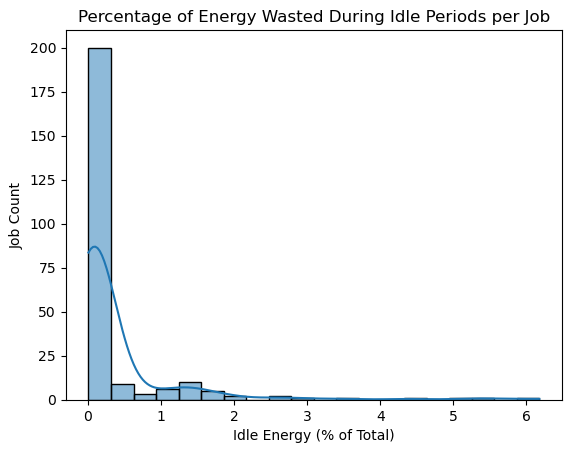

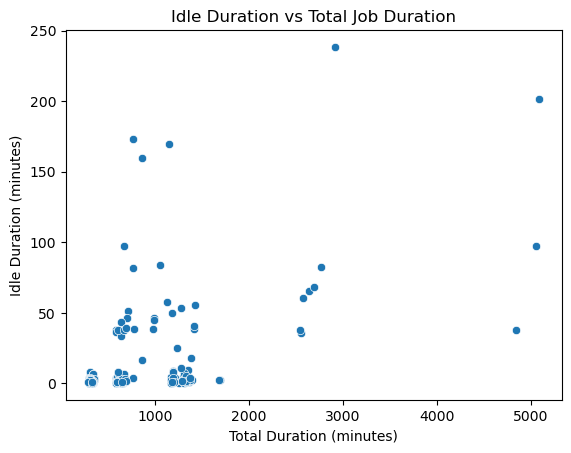

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of wasted energy
sns.histplot(report_df['idle_pct_energy'], bins=20, kde=True)
plt.title("Percentage of Energy Wasted During Idle Periods per Job")
plt.xlabel("Idle Energy (% of Total)")
plt.ylabel("Job Count")
plt.show()

# Idle duration vs total job duration
sns.scatterplot(data=report_df, x='total_duration_min', y='idle_duration_min')
plt.title("Idle Duration vs Total Job Duration")
plt.xlabel("Total Duration (minutes)")
plt.ylabel("Idle Duration (minutes)")
plt.show()


In [ ]:
### Potential savings due to gpu downclock

In [13]:
import pandas as pd

# Assuming df already loaded
# df = pd.read_csv("all_jobs.csv")

# Parameters
IDLE_THRESHOLD = 30      # Utilization (%) below which GPU is considered idle
INTERVAL_SECONDS = 10    # Granularity of your dataset (10s resampled)

# Detect idle periods
df['is_idle'] = df['utilization_gpu_pct'] < IDLE_THRESHOLD

# Actual energy (Joules)
df['total_energy_J'] = df['power_draw_W'] * INTERVAL_SECONDS

# Idle energy (wasted)
df['idle_energy_J'] = df['is_idle'] * df['power_draw_W'] * INTERVAL_SECONDS

# Simulated energy if downclocking saves 50% idle power
df['idle_energy_saving_J'] = df['is_idle'] * (df['power_draw_W'] * 0.5) * INTERVAL_SECONDS

# Aggregate per job
report_df = df.groupby('id_job').agg(
    total_energy_J=('total_energy_J', 'sum'),
    idle_energy_J=('idle_energy_J', 'sum'),
    idle_energy_saving_J=('idle_energy_saving_J', 'sum'),
    idle_duration_steps=('is_idle', 'sum'),
    total_steps=('is_idle', 'count')
).reset_index()

# Convert units
report_df['idle_pct_energy'] = report_df['idle_energy_J'] / report_df['total_energy_J'] * 100
report_df['idle_duration_min'] = report_df['idle_duration_steps'] * INTERVAL_SECONDS / 60
report_df['total_duration_min'] = report_df['total_steps'] * INTERVAL_SECONDS / 60

# Compute savings
report_df['potential_saving_J'] = report_df['idle_energy_J'] - report_df['idle_energy_saving_J']
report_df['potential_saving_pct'] = report_df['potential_saving_J'] / report_df['total_energy_J'] * 100

# Save report
report_df.to_csv("idle_gpu_energy_savings_report.csv", index=False)

print(report_df[['id_job','total_energy_J','idle_energy_J','potential_saving_J','potential_saving_pct']].head())


          id_job  total_energy_J  idle_energy_J  potential_saving_J  \
0    70053314562    8.020975e+06    1328.018428          664.009214   
1   531177744168    7.550286e+06    2940.841055         1470.420527   
2   611401690860    1.587713e+07    1329.376251          664.688125   
3   772032503727    7.713671e+06    3157.643335         1578.821668   
4  1173416277102    3.950320e+06   19613.598928         9806.799464   

   potential_saving_pct  
0              0.008278  
1              0.019475  
2              0.004186  
3              0.020468  
4              0.248253  


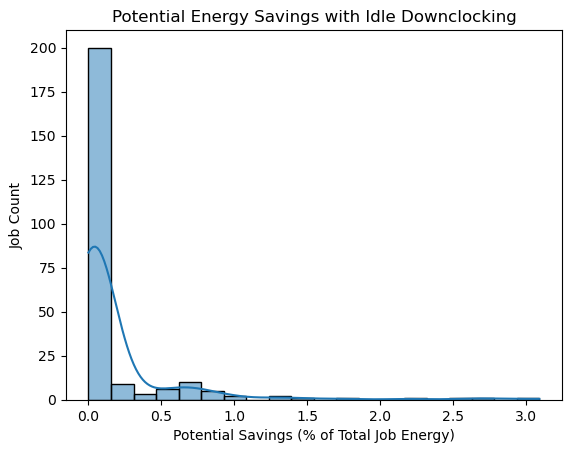

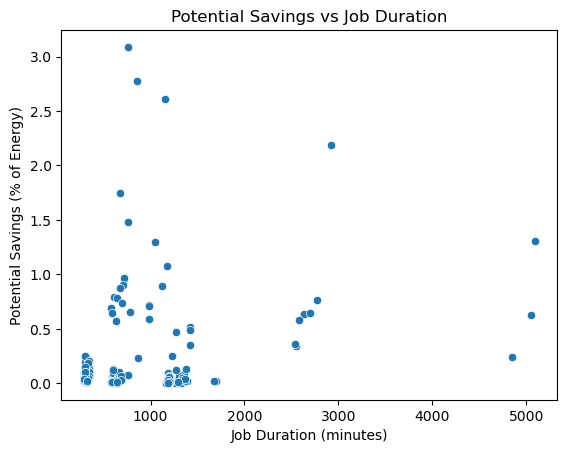

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram of potential savings across jobs
sns.histplot(report_df['potential_saving_pct'], bins=20, kde=True)
plt.title("Potential Energy Savings with Idle Downclocking")
plt.xlabel("Potential Savings (% of Total Job Energy)")
plt.ylabel("Job Count")
plt.show()

# Scatter plot: Job duration vs savings
sns.scatterplot(data=report_df, x='total_duration_min', y='potential_saving_pct')
plt.title("Potential Savings vs Job Duration")
plt.xlabel("Job Duration (minutes)")
plt.ylabel("Potential Savings (% of Energy)")
plt.show()


In [15]:
# === Cluster-wide summary ===
total_energy = report_df['total_energy_J'].sum()
total_idle_energy = report_df['idle_energy_J'].sum()
total_potential_saving = report_df['potential_saving_J'].sum()

cluster_summary = {
    "Cluster Total Energy (GJ)": total_energy / 1e9,
    "Cluster Idle Energy (GJ)": total_idle_energy / 1e9,
    "Cluster Potential Saving (GJ)": total_potential_saving / 1e9,
    "Cluster Potential Saving (%)": (total_potential_saving / total_energy) * 100
}


In [17]:
print("\n=== Cluster-Wide Summary ===")
for k,v in cluster_summary.items():
    print(f"{k}: {v:.5f}")


=== Cluster-Wide Summary ===
Cluster Total Energy (GJ): 2.19090
Cluster Idle Energy (GJ): 0.00666
Cluster Potential Saving (GJ): 0.00333
Cluster Potential Saving (%): 0.15207
